In [1]:
import polars as pl
import seaborn as sns
import matplotlib as mat
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [2]:
df = pl.read_csv("bank.csv", separator=";")

In [3]:
df.head()

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
i64,str,str,str,str,i64,str,str,str,i64,str,i64,i64,i64,i64,str,str
30,"""unemployed""","""married""","""primary""","""no""",1787,"""no""","""no""","""cellular""",19,"""oct""",79,1,-1,0,"""unknown""","""no"""
33,"""services""","""married""","""secondary""","""no""",4789,"""yes""","""yes""","""cellular""",11,"""may""",220,1,339,4,"""failure""","""no"""
35,"""management""","""single""","""tertiary""","""no""",1350,"""yes""","""no""","""cellular""",16,"""apr""",185,1,330,1,"""failure""","""no"""
30,"""management""","""married""","""tertiary""","""no""",1476,"""yes""","""yes""","""unknown""",3,"""jun""",199,4,-1,0,"""unknown""","""no"""
59,"""blue-collar""","""married""","""secondary""","""no""",0,"""yes""","""no""","""unknown""",5,"""may""",226,1,-1,0,"""unknown""","""no"""


In [4]:
df.shape

(4521, 17)

In [5]:
# Verificar quantidade de campos nulos
df.null_count()

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
#Verificar quantidade de valores em cada coluna
for col in df.columns:
    print(f"Contagem de valores em {col}:")
    print(df[col].value_counts())


Contagem de valores em age:
shape: (67, 2)
┌─────┬───────┐
│ age ┆ count │
│ --- ┆ ---   │
│ i64 ┆ u32   │
╞═════╪═══════╡
│ 36  ┆ 188   │
│ 60  ┆ 47    │
│ 40  ┆ 142   │
│ 45  ┆ 112   │
│ 19  ┆ 4     │
│ …   ┆ …     │
│ 83  ┆ 4     │
│ 86  ┆ 1     │
│ 35  ┆ 180   │
│ 77  ┆ 6     │
│ 44  ┆ 105   │
└─────┴───────┘
Contagem de valores em job:
shape: (12, 2)
┌───────────────┬───────┐
│ job           ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ blue-collar   ┆ 946   │
│ entrepreneur  ┆ 168   │
│ self-employed ┆ 183   │
│ technician    ┆ 768   │
│ unemployed    ┆ 128   │
│ …             ┆ …     │
│ management    ┆ 969   │
│ services      ┆ 417   │
│ housemaid     ┆ 112   │
│ retired       ┆ 230   │
│ admin.        ┆ 478   │
└───────────────┴───────┘
Contagem de valores em marital:
shape: (3, 2)
┌──────────┬───────┐
│ marital  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ married  ┆ 2797  │
│ divorced ┆ 528   │
│ singl

In [7]:
#Coluna com mais de 70% dos valores desconhecidos. Será removida
df.drop('poutcome')

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,y
i64,str,str,str,str,i64,str,str,str,i64,str,i64,i64,i64,i64,str
30,"""unemployed""","""married""","""primary""","""no""",1787,"""no""","""no""","""cellular""",19,"""oct""",79,1,-1,0,"""no"""
33,"""services""","""married""","""secondary""","""no""",4789,"""yes""","""yes""","""cellular""",11,"""may""",220,1,339,4,"""no"""
35,"""management""","""single""","""tertiary""","""no""",1350,"""yes""","""no""","""cellular""",16,"""apr""",185,1,330,1,"""no"""
30,"""management""","""married""","""tertiary""","""no""",1476,"""yes""","""yes""","""unknown""",3,"""jun""",199,4,-1,0,"""no"""
59,"""blue-collar""","""married""","""secondary""","""no""",0,"""yes""","""no""","""unknown""",5,"""may""",226,1,-1,0,"""no"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33,"""services""","""married""","""secondary""","""no""",-333,"""yes""","""no""","""cellular""",30,"""jul""",329,5,-1,0,"""no"""
57,"""self-employed""","""married""","""tertiary""","""yes""",-3313,"""yes""","""yes""","""unknown""",9,"""may""",153,1,-1,0,"""no"""
57,"""technician""","""married""","""secondary""","""no""",295,"""no""","""no""","""cellular""",19,"""aug""",151,11,-1,0,"""no"""


In [8]:
#Separando os grupos que aceitaram contratar o produto e os que não aceitaram
df_yes = df.filter(pl.col("y") == "yes")
df_no = df.filter(pl.col("y") == "no")

C:\Users\vilia\AppData\Local\Temp\ipykernel_4864\1667950712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="duration", data=df, notch=True, palette="deep")


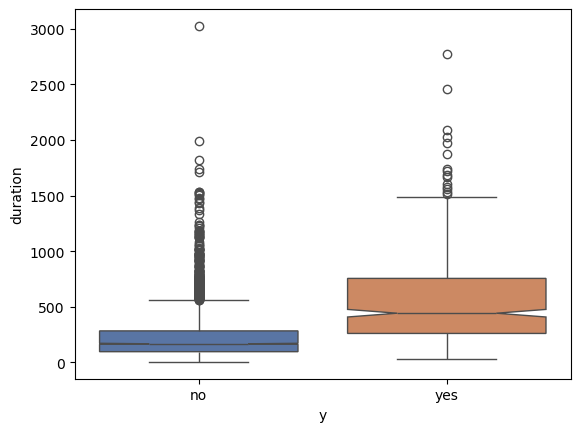

In [9]:
#Comparando a duração de tempo de contato entre quem contratou ou não
sns.boxplot(x="y", y="duration", data=df, notch=True, palette="deep")
plt.show()


C:\Users\vilia\AppData\Local\Temp\ipykernel_4864\1960889687.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="pdays", data=df, palette="bright")


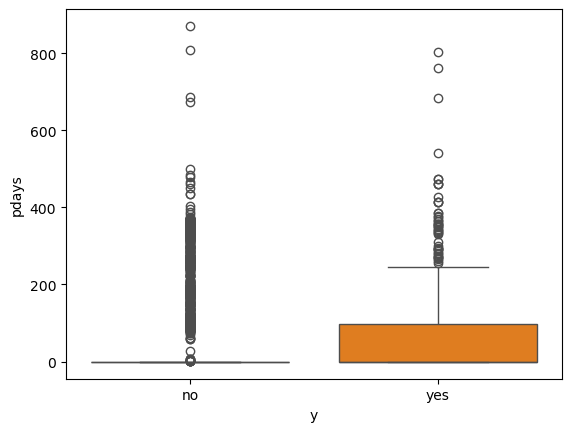

In [10]:
#Tempo em dias do último contato. Ninguém que aceitou o produto foi abordado pela primeira vez
sns.boxplot(x="y", y="pdays", data=df, palette="bright")
plt.show()

C:\Users\vilia\AppData\Local\Temp\ipykernel_4864\3483468948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="age", notch=True, palette="pastel")


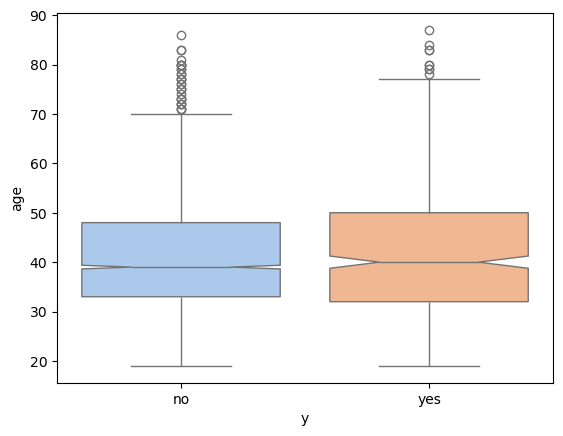

In [11]:
# Comparando idade dos clientes que aplicaram ou não no investimento oferecido.
sns.boxplot(data=df, x="y", y="age", notch=True, palette="pastel")
plt.show()

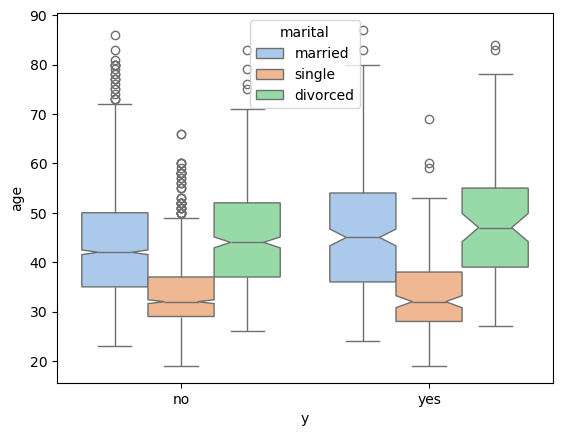

In [12]:
#Comparando idade, estado civil para verificar se há diferença entre quem contratou ou não
sns.boxplot(data=df, x="y", y="age", hue="marital", notch=True, palette="pastel")
plt.show()

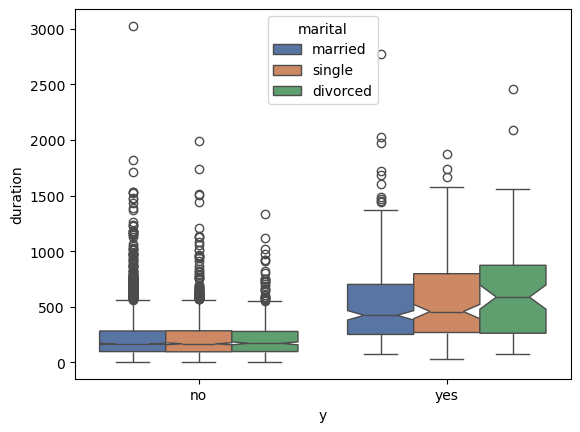

In [13]:
#Comparando duração do atendimento, estado civil para verificar se há diferença entre quem contratou ou não
sns.boxplot(data=df, x="y", y="duration", hue="marital", notch=True, palette="deep")
plt.show()

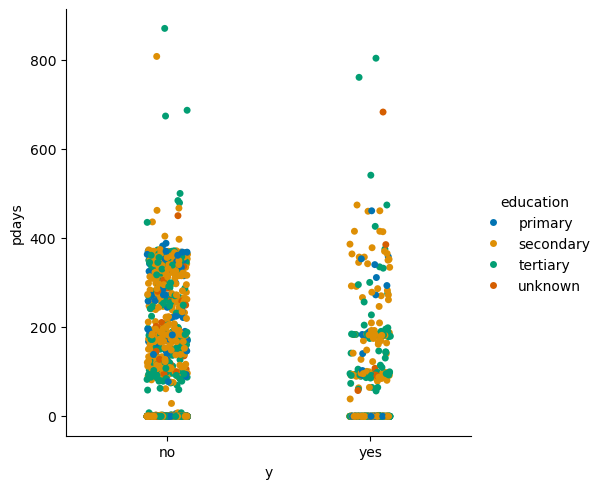

In [14]:
#Comparando tempo do último contato, escolaridade para verificar se há diferença entre quem contratou ou não
sns.catplot(data=df, x="y", y="pdays", hue="education", palette="colorblind")
plt.show()

In [15]:
#Criando nova coluna de faixa etária, para posterior análise
df = df.with_columns(
    pl.when(pl.col("age").is_between(18, 30))
    .then(pl.lit("18-30"))
    .when(pl.col("age").is_between(31, 45))
    .then(pl.lit("31-45"))
    .when(pl.col("age").is_between(46, 60))
    .then(pl.lit("46-60"))
    .when(pl.col("age") > 60)
    .then(pl.lit("+60"))
    .otherwise(None) # Caso a idade seja menor que 18
    .alias("faixa_etaria")
)

df.head(50)

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,faixa_etaria
i64,str,str,str,str,i64,str,str,str,i64,str,i64,i64,i64,i64,str,str,str
30,"""unemployed""","""married""","""primary""","""no""",1787,"""no""","""no""","""cellular""",19,"""oct""",79,1,-1,0,"""unknown""","""no""","""18-30"""
33,"""services""","""married""","""secondary""","""no""",4789,"""yes""","""yes""","""cellular""",11,"""may""",220,1,339,4,"""failure""","""no""","""31-45"""
35,"""management""","""single""","""tertiary""","""no""",1350,"""yes""","""no""","""cellular""",16,"""apr""",185,1,330,1,"""failure""","""no""","""31-45"""
30,"""management""","""married""","""tertiary""","""no""",1476,"""yes""","""yes""","""unknown""",3,"""jun""",199,4,-1,0,"""unknown""","""no""","""18-30"""
59,"""blue-collar""","""married""","""secondary""","""no""",0,"""yes""","""no""","""unknown""",5,"""may""",226,1,-1,0,"""unknown""","""no""","""46-60"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
34,"""management""","""single""","""tertiary""","""no""",872,"""yes""","""no""","""unknown""",7,"""may""",105,2,-1,0,"""unknown""","""no""","""31-45"""
55,"""blue-collar""","""married""","""primary""","""no""",145,"""no""","""no""","""telephone""",2,"""feb""",59,3,5,2,"""other""","""no""","""46-60"""
26,"""blue-collar""","""married""","""primary""","""no""",0,"""yes""","""no""","""unknown""",21,"""may""",425,1,-1,0,"""unknown""","""no""","""18-30"""


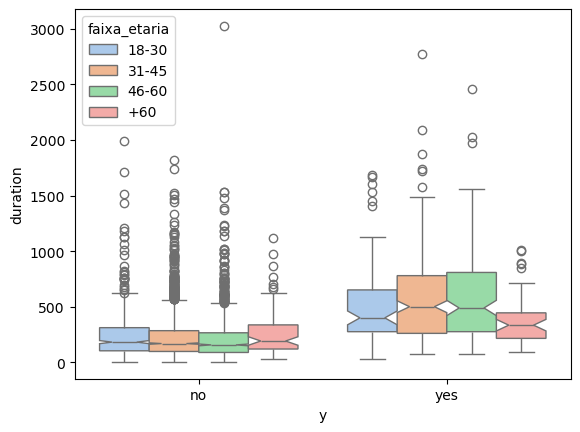

In [16]:
#Comparando faixa etária
sns.boxplot(data=df, x="y", y="duration", hue="faixa_etaria", notch=True, palette="pastel")
plt.show()

In [18]:
#Como há forte relação entre duração do contato com aceitar o produto, vou analisar os dados estatísticos
df_no.describe()

statistic,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
str,f64,str,str,str,str,f64,str,str,str,f64,str,f64,f64,f64,f64,str,str
"""count""",4000.0,"""4000""","""4000""","""4000""","""4000""",4000.0,"""4000""","""4000""","""4000""",4000.0,"""4000""",4000.0,4000.0,4000.0,4000.0,"""4000""","""4000"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0"""
"""mean""",40.998,null,null,null,null,1403.21175,null,null,null,15.94875,null,226.3475,2.86225,36.006,0.47125,null,null
"""std""",10.188398,null,null,null,null,3075.349313,null,null,null,8.249736,null,210.313631,3.212609,96.297657,1.627371,null,null
"""min""",19.0,"""admin.""","""divorced""","""primary""","""no""",-3313.0,"""no""","""no""","""cellular""",1.0,"""apr""",4.0,1.0,-1.0,0.0,"""failure""","""no"""
"""25%""",33.0,null,null,null,null,61.0,null,null,null,8.0,null,96.0,1.0,-1.0,0.0,null,null
"""50%""",39.0,null,null,null,null,420.0,null,null,null,16.0,null,167.0,2.0,-1.0,0.0,null,null
"""75%""",48.0,null,null,null,null,1407.0,null,null,null,21.0,null,283.0,3.0,-1.0,0.0,null,null
"""max""",86.0,"""unknown""","""single""","""unknown""","""yes""",71188.0,"""yes""","""yes""","""unknown""",31.0,"""sep""",3025.0,50.0,871.0,25.0,"""unknown""","""no"""


In [19]:
df_yes.describe()

statistic,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
str,f64,str,str,str,str,f64,str,str,str,f64,str,f64,f64,f64,f64,str,str
"""count""",521.0,"""521""","""521""","""521""","""521""",521.0,"""521""","""521""","""521""",521.0,"""521""",521.0,521.0,521.0,521.0,"""521""","""521"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0"""
"""mean""",42.491363,null,null,null,null,1571.955854,null,null,null,15.658349,null,552.742802,2.266795,68.639155,1.090211,null,null
"""std""",13.115772,null,null,null,null,2444.398956,null,null,null,8.235148,null,390.325805,2.092071,121.963063,2.055368,null,null
"""min""",19.0,"""admin.""","""divorced""","""primary""","""no""",-1206.0,"""no""","""no""","""cellular""",1.0,"""apr""",30.0,1.0,-1.0,0.0,"""failure""","""yes"""
"""25%""",32.0,null,null,null,null,171.0,null,null,null,9.0,null,260.0,1.0,-1.0,0.0,null,null
"""50%""",40.0,null,null,null,null,710.0,null,null,null,15.0,null,442.0,2.0,-1.0,0.0,null,null
"""75%""",50.0,null,null,null,null,2160.0,null,null,null,22.0,null,755.0,3.0,98.0,2.0,null,null
"""max""",87.0,"""unknown""","""single""","""unknown""","""yes""",26965.0,"""yes""","""yes""","""unknown""",31.0,"""sep""",2769.0,24.0,804.0,14.0,"""unknown""","""yes"""


In [31]:
#Vou fazer um recorte do último quartil do não, para verificar padrões com o sim. Contatos que duraram 283 segundos ou mais. Juntando os dataframes usando a função o concat do polars
df_no_quartil = df.filter((pl.col("duration") >= 283) & (pl.col("y") == "no"))
df_yes_novo = df.filter(pl.col("y") == "yes")
df_junto = pl.concat([df_no_quartil, df_yes_novo])
df_junto.shape

(1524, 18)

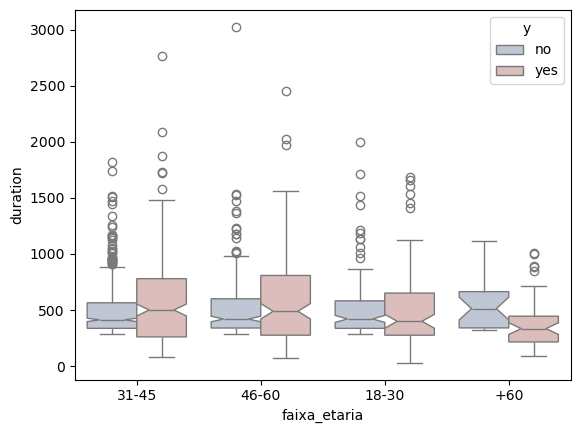

In [37]:
#Verificando se há algum padrão na faixa etaria, comparando o primeiro quartil do no, com todo o yes. Faixa mais jovem há aproximação na duração do contato
#Outra observação é que idosos com do não tiveram contatos mais longos que idosos que aceitaram o produto
sns.boxplot(data=df_junto, x="faixa_etaria", y="duration", hue="y", notch=True, palette="vlag")
plt.show()

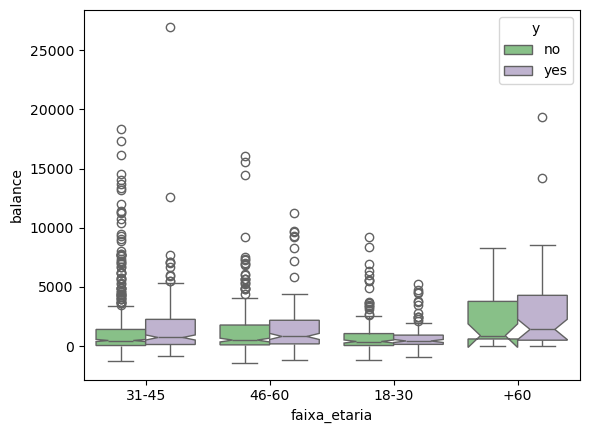

In [36]:
#Comparação com saldo nesse grupo
sns.boxplot(data=df_junto, x="faixa_etaria", y="balance", hue="y", notch=True, palette="Accent")
plt.show()